In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/price_history.csv')
print(df.shape)
print(df.dtypes)
df.head()

(8204, 10)
platform             str
category             str
name                 str
brand                str
seller               str
seller_rating        str
link                 str
base_price       float64
current_price    float64
checked_at           str
dtype: object


,platform,category,name,brand,seller,seller_rating,link,base_price,current_price,checked_at
0,Trendyol,laptop,Ideapad Slim 3 AMD Ryzen 5-7520U 8GB 512GB SSD...,LENOVO,Trendyol,9.2,https://www.trendyol.com/lenovo/ideapad-slim-3...,19499.0,19999.0,2026-05-15 18:45:04
1,Trendyol,laptop,"LOQE AMD Ryzen 7-7735HS 16GB 512GB SSD 15.6"" F...",LENOVO,Trendyol,9.2,https://www.trendyol.com/lenovo/loqe-amd-ryzen...,37999.0,39999.0,2026-05-15 18:45:04
2,Trendyol,laptop,"13"" MacBook Neo Indigo 512GB",Apple,Trendyol,9.2,https://www.trendyol.com/apple/13-macbook-neo-...,38299.0,38299.0,2026-05-15 18:45:04
3,Trendyol,laptop,"LOQ E AMD Ryzen 5-7535HS 16GB 512GB SSD 15.6"" ...",LENOVO,Trendyol,9.2,https://www.trendyol.com/lenovo/loq-e-amd-ryze...,34999.0,37499.0,2026-05-15 18:45:04
4,Trendyol,laptop,Victus AMD Ryzen 5-8645HS 16GB 512GB RTX3050 6...,HP,Trendyol,9.2,https://www.trendyol.com/hp/victus-amd-ryzen-5...,34999.0,36999.0,2026-05-15 18:45:04


In [2]:
# checked_at kolonunu datetime'a çevir
df['checked_at'] = pd.to_datetime(df['checked_at'])

# Fiyat değişimi kolonunu hesapla
df['price_change'] = df['current_price'] - df['base_price']
df['price_change_pct'] = ((df['current_price'] - df['base_price']) / df['base_price']) * 100

# Aykırı değerleri temizle (100 TL altı fiyatlar hatalı)
df = df[df['current_price'] > 100]

# Eksik fiyatları düşür
df = df.dropna(subset=['current_price', 'base_price'])

print(f"Temizlenen veri: {df.shape}")
print(f"Eksik değerler:\n{df.isnull().sum()}")

Temizlenen veri: (8152, 12)
Eksik değerler:
platform               0
category               0
name                   0
brand                  0
seller               374
seller_rating       4204
link                   0
base_price             0
current_price          0
checked_at             0
price_change           0
price_change_pct       0
dtype: int64


In [3]:
# Platform dağılımı
print("Platform dağılımı:")
print(df['platform'].value_counts())

print("\nKategori dağılımı:")
print(df['category'].value_counts())

print("\nOrtalama fiyatlar (platforma göre):")
print(df.groupby('platform')['current_price'].mean().round(2))

print("\nOrtalama fiyatlar (kategoriye göre):")
print(df.groupby('category')['current_price'].mean().round(2))

Platform dağılımı:
platform
Hepsiburada    2750
Trendyol       2727
MediaMarkt     2675
Name: count, dtype: int64

Kategori dağılımı:
category
laptop         1654
telefon        1639
kulaklık       1628
akıllı saat    1617
tablet         1614
Name: count, dtype: int64

Ortalama fiyatlar (platforma göre):
platform
Hepsiburada    21283.58
MediaMarkt     30926.04
Trendyol       19798.22
Name: current_price, dtype: float64

Ortalama fiyatlar (kategoriye göre):
category
akıllı saat     7022.17
kulaklık        2911.74
laptop         50052.88
tablet         14281.53
telefon        44730.76
Name: current_price, dtype: float64


In [ ]:
#GÖRSELLEŞTİRME

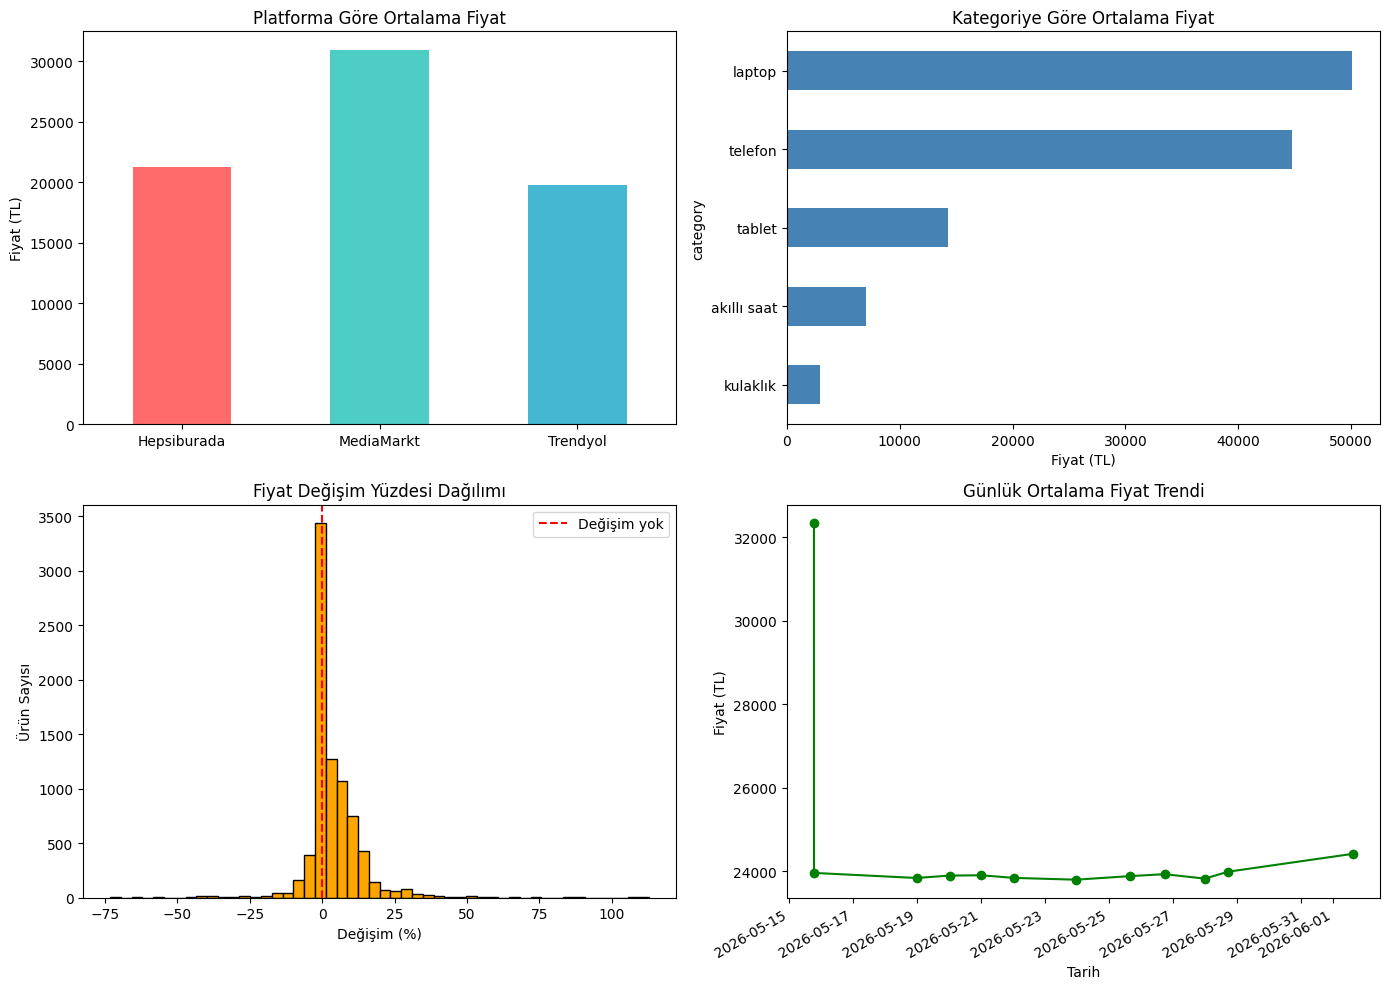

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Platform bazında ortalama fiyat
df.groupby('platform')['current_price'].mean().plot(kind='bar', ax=axes[0,0], color=['#FF6B6B','#4ECDC4','#45B7D1'])
axes[0,0].set_title('Platforma Göre Ortalama Fiyat')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Fiyat (TL)')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Kategori bazında ortalama fiyat
df.groupby('category')['current_price'].mean().sort_values().plot(kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Kategoriye Göre Ortalama Fiyat')
axes[0,1].set_xlabel('Fiyat (TL)')

# 3. Fiyat değişim yüzdesi dağılımı
axes[1,0].hist(df['price_change_pct'], bins=50, color='orange', edgecolor='black')
axes[1,0].set_title('Fiyat Değişim Yüzdesi Dağılımı')
axes[1,0].set_xlabel('Değişim (%)')
axes[1,0].set_ylabel('Ürün Sayısı')
axes[1,0].axvline(0, color='red', linestyle='--', label='Değişim yok')
axes[1,0].legend()

# 4. Günlük ortalama fiyat trendi
df.groupby('checked_at')['current_price'].mean().plot(ax=axes[1,1], color='green', marker='o')
axes[1,1].set_title('Günlük Ortalama Fiyat Trendi')
axes[1,1].set_xlabel('Tarih')
axes[1,1].set_ylabel('Fiyat (TL)')

plt.tight_layout()
plt.savefig('../visuals/eda_gorseller.png', dpi=150)
plt.show()

In [ ]:
#MODELLEME

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Feature engineering
df_model = df.copy()

# Kategorik değişkenleri encode et
le_platform = LabelEncoder()
le_category = LabelEncoder()

df_model['platform_enc'] = le_platform.fit_transform(df_model['platform'])
df_model['category_enc'] = le_category.fit_transform(df_model['category'])

# Özellikler ve hedef
X = df_model[['platform_enc', 'category_enc', 'base_price']]
y = df_model['current_price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim seti: {X_train.shape}")
print(f"Test seti: {X_test.shape}")

Eğitim seti: (6521, 3)
Test seti: (1631, 3)


In [7]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("=" * 40)
print(f"Linear Regression:")
print(f"  RMSE : {rmse_lr:.2f} TL")
print(f"  R²   : {r2_lr:.4f}")
print("=" * 40)
print(f"Random Forest:")
print(f"  RMSE : {rmse_rf:.2f} TL")
print(f"  R²   : {r2_rf:.4f}")
print("=" * 40)

Linear Regression:
  RMSE : 2065.74 TL
  R²   : 0.9958
Random Forest:
  RMSE : 1285.05 TL
  R²   : 0.9984


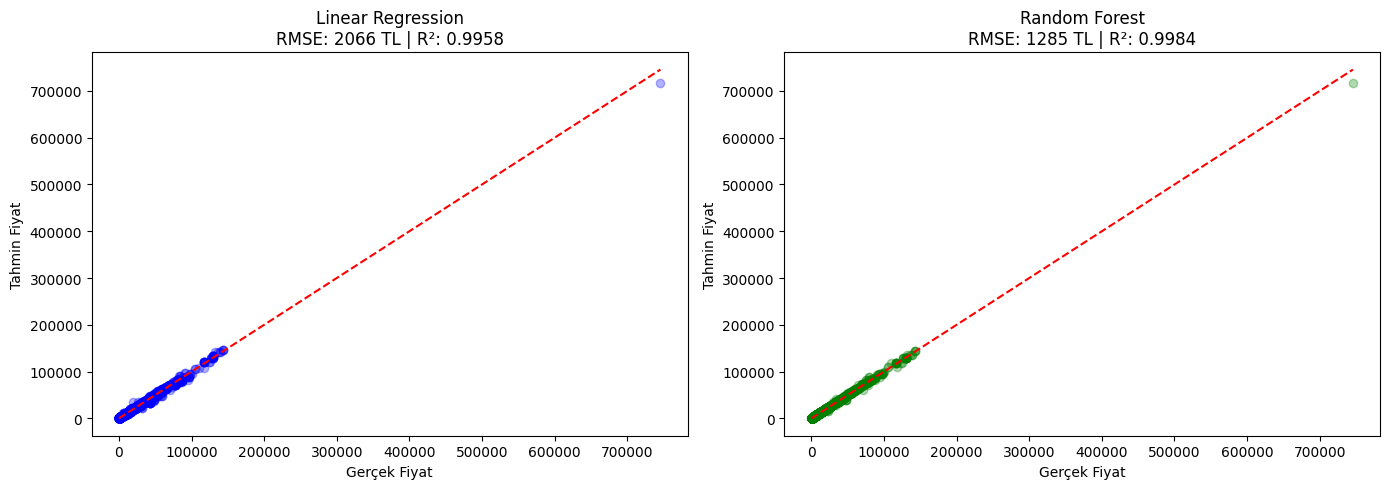

In [8]:
# Model karşılaştırma grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gerçek vs Tahmin - Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.3, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title(f'Linear Regression\nRMSE: {rmse_lr:.0f} TL | R²: {r2_lr:.4f}')
axes[0].set_xlabel('Gerçek Fiyat')
axes[0].set_ylabel('Tahmin Fiyat')

# Gerçek vs Tahmin - Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title(f'Random Forest\nRMSE: {rmse_rf:.0f} TL | R²: {r2_rf:.4f}')
axes[1].set_xlabel('Gerçek Fiyat')
axes[1].set_ylabel('Tahmin Fiyat')

plt.tight_layout()
plt.savefig('../visuals/model_karsilastirma.png', dpi=150)
plt.show()

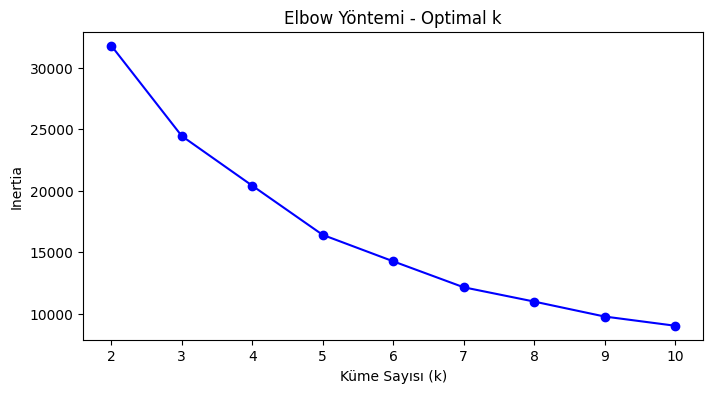

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# df_model kullan, encode edilmiş kolonlar orada
df_cluster = df_model[['base_price', 'current_price', 'price_change_pct', 'platform_enc', 'category_enc']].dropna()

# Normalize et
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Optimal k bulmak için Elbow yöntemi
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('Inertia')
plt.title('Elbow Yöntemi - Optimal k')
plt.savefig('../visuals/elbow.png', dpi=150)
plt.show()

In [ ]:
# K-MEANS K=5 SEÇTİK

Küme bazında ortalama değerler:
         base_price  current_price  price_change_pct
cluster                                             
0           5532.01        5681.31              2.74
1          25478.60       25716.65              0.58
2         700601.78      719135.90              2.65
3          80167.53       82341.88              2.92
4          11657.72       12643.65              8.05


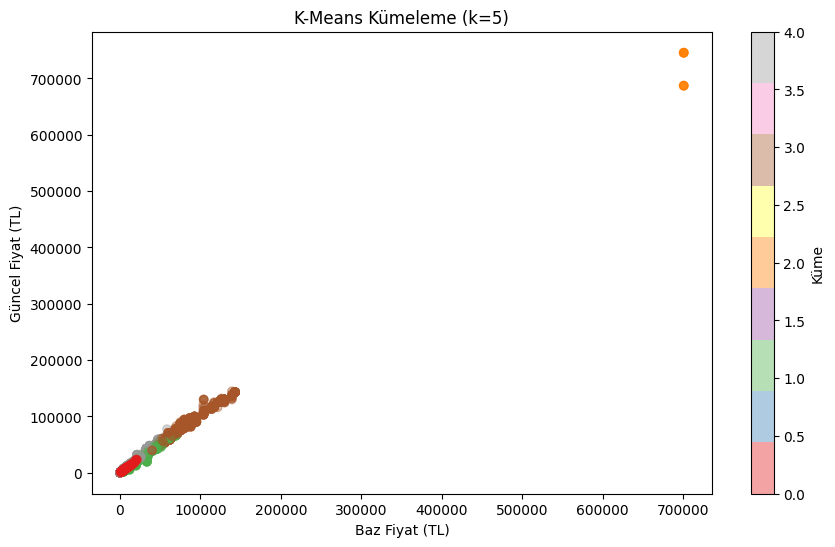

In [11]:
# K-Means ile k=5
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df_model['cluster'] = km.fit_predict(X_scaled)

# Küme analizi
print("Küme bazında ortalama değerler:")
print(df_model.groupby('cluster')[['base_price', 'current_price', 'price_change_pct']].mean().round(2))

# Küme görselleştirme
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_model['base_price'], df_model['current_price'], 
                      c=df_model['cluster'], cmap='Set1', alpha=0.4)
plt.colorbar(scatter, label='Küme')
plt.xlabel('Baz Fiyat (TL)')
plt.ylabel('Güncel Fiyat (TL)')
plt.title('K-Means Kümeleme (k=5)')
plt.savefig('../visuals/kmeans.png', dpi=150)
plt.show()

In [ ]:
#Küme 2 aykırı değer yüzünden bozulmuş. O ürünü çıkarıp tekrar çalıştıralım. Yeni hücreye:

Temizlenmiş küme analizi:
         base_price  current_price  price_change_pct
cluster                                             
0          23347.42       23568.12              0.55
1          18360.58       19734.32              7.03
2           5384.41        5471.89              1.84
3           3960.28        4434.29              9.87
4          78164.48       80226.65              2.86


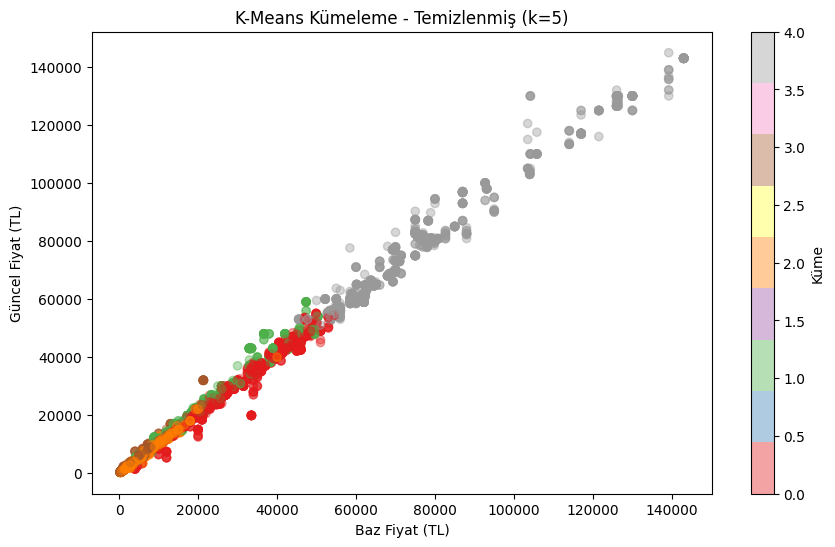

In [12]:
# Aykırı değeri çıkar ve tekrar kümele
df_model_clean = df_model[df_model['base_price'] < 200000].copy()

X_clean = scaler.fit_transform(df_model_clean[['base_price', 'current_price', 
                                                'price_change_pct', 'platform_enc', 'category_enc']])

km_clean = KMeans(n_clusters=5, random_state=42, n_init=10)
df_model_clean['cluster'] = km_clean.fit_predict(X_clean)

print("Temizlenmiş küme analizi:")
print(df_model_clean.groupby('cluster')[['base_price', 'current_price', 'price_change_pct']].mean().round(2))

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_model_clean['base_price'], df_model_clean['current_price'],
                      c=df_model_clean['cluster'], cmap='Set1', alpha=0.4)
plt.colorbar(scatter, label='Küme')
plt.xlabel('Baz Fiyat (TL)')
plt.ylabel('Güncel Fiyat (TL)')
plt.title('K-Means Kümeleme - Temizlenmiş (k=5)')
plt.savefig('../visuals/kmeans_clean.png', dpi=150)
plt.show()